# Week 8: Hyperparameter Sweep Analysis

## Objective

This notebook analyses the results of six TrashNet hyperparameter sweep experiments using EfficientNetB0.

The sweep studied three hyperparameters:

- Image size
- Dropout rate
- Data augmentation strength

The objectives are to:

- Compare all six experiment configurations
- Sort the runs by validation accuracy
- Identify the best-performing combination
- Study the approximate effect of each hyperparameter
- Select suitable default settings for the future CESPPL dataset experiments

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
experiment_data = {
    "run_id": [1, 2, 3, 4, 5, 6],

    "image_size": [
        160,
        160,
        224,
        224,
        260,
        260
    ],

    "dropout": [
        0.2,
        0.5,
        0.3,
        0.5,
        0.2,
        0.5
    ],

    "augmentation_level": [
        "Low",
        "High",
        "Medium",
        "Low",
        "High",
        "Medium"
    ],

    "train_acc": [
        94.16,
        84.42,
        91.89,
        90.41,
        90.36,
        83.33
    ],

    "val_acc": [
        87.13,
        84.55,
        86.73,
        87.72,
        87.72,
        89.31
    ],

    "test_acc": [
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "N/A",
        "N/A"
    ],

    "training_time_minutes": [
        3.51,
        3.72,
        3.95,
        3.85,
        4.99,
        4.86
    ],

    "notes": [
        "Low augmentation",
        "High augmentation",
        "Medium augmentation",
        "Low augmentation",
        "High augmentation",
        "Medium augmentation"
    ]
}

df = pd.DataFrame(experiment_data)

df

,run_id,image_size,dropout,augmentation_level,train_acc,val_acc,test_acc,training_time_minutes,notes
0,1,160,0.2,Low,94.16,87.13,N/A,3.51,Low augmentation
1,2,160,0.5,High,84.42,84.55,N/A,3.72,High augmentation
2,3,224,0.3,Medium,91.89,86.73,N/A,3.95,Medium augmentation
3,4,224,0.5,Low,90.41,87.72,N/A,3.85,Low augmentation
4,5,260,0.2,High,90.36,87.72,N/A,4.99,High augmentation
5,6,260,0.5,Medium,83.33,89.31,N/A,4.86,Medium augmentation


In [4]:
CSV_PATH = "/content/drive/MyDrive/experiments_clean.csv"

df.to_csv(
    CSV_PATH,
    index=False
)

print("Corrected experiments CSV saved to:")
print(CSV_PATH)

Corrected experiments CSV saved to:
/content/drive/MyDrive/experiments_clean.csv


In [5]:
print(df.dtypes)

run_id                     int64
image_size                 int64
dropout                  float64
augmentation_level        object
train_acc                float64
val_acc                  float64
test_acc                  object
training_time_minutes    float64
notes                     object
dtype: object


In [6]:
sorted_results = df.sort_values(
    by="val_acc",
    ascending=False
).reset_index(drop=True)

sorted_results

,run_id,image_size,dropout,augmentation_level,train_acc,val_acc,test_acc,training_time_minutes,notes
0,6,260,0.5,Medium,83.33,89.31,N/A,4.86,Medium augmentation
1,4,224,0.5,Low,90.41,87.72,N/A,3.85,Low augmentation
2,5,260,0.2,High,90.36,87.72,N/A,4.99,High augmentation
3,1,160,0.2,Low,94.16,87.13,N/A,3.51,Low augmentation
4,3,224,0.3,Medium,91.89,86.73,N/A,3.95,Medium augmentation
5,2,160,0.5,High,84.42,84.55,N/A,3.72,High augmentation


In [7]:
best_run = sorted_results.iloc[0]

print("=" * 50)
print("BEST HYPERPARAMETER COMBINATION")
print("=" * 50)

print(f"Run ID: {int(best_run['run_id'])}")
print(f"Image Size: {int(best_run['image_size'])}")
print(f"Dropout: {best_run['dropout']}")
print(
    f"Augmentation Level: "
    f"{best_run['augmentation_level']}"
)
print(
    f"Training Accuracy: "
    f"{best_run['train_acc']:.2f}%"
)
print(
    f"Validation Accuracy: "
    f"{best_run['val_acc']:.2f}%"
)
print(
    f"Training Time: "
    f"{best_run['training_time_minutes']:.2f} minutes"
)

BEST HYPERPARAMETER COMBINATION
Run ID: 6
Image Size: 260
Dropout: 0.5
Augmentation Level: Medium
Training Accuracy: 83.33%
Validation Accuracy: 89.31%
Training Time: 4.86 minutes


In [8]:
ranked_table = sorted_results[
    [
        "run_id",
        "image_size",
        "dropout",
        "augmentation_level",
        "train_acc",
        "val_acc",
        "training_time_minutes"
    ]
]

ranked_table

,run_id,image_size,dropout,augmentation_level,train_acc,val_acc,training_time_minutes
0,6,260,0.5,Medium,83.33,89.31,4.86
1,4,224,0.5,Low,90.41,87.72,3.85
2,5,260,0.2,High,90.36,87.72,4.99
3,1,160,0.2,Low,94.16,87.13,3.51
4,3,224,0.3,Medium,91.89,86.73,3.95
5,2,160,0.5,High,84.42,84.55,3.72


In [9]:
image_size_results = (
    df.groupby("image_size", as_index=False)
    ["val_acc"]
    .mean()
    .sort_values("image_size")
)

image_size_results

,image_size,val_acc
0,160,85.840
1,224,87.225
2,260,88.515


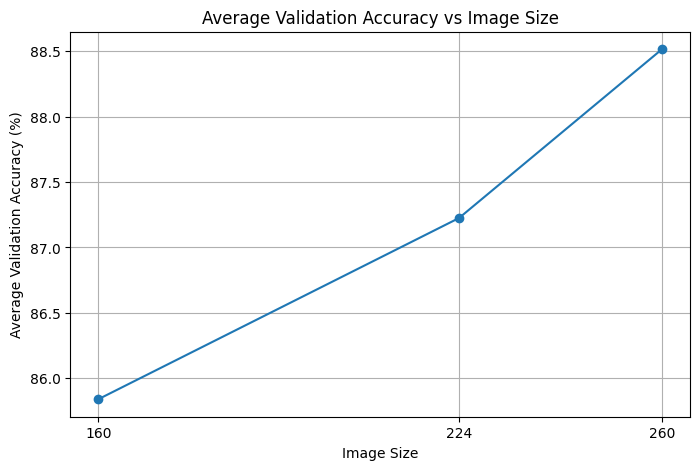

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    image_size_results["image_size"],
    image_size_results["val_acc"],
    marker="o"
)

plt.title(
    "Average Validation Accuracy vs Image Size"
)

plt.xlabel("Image Size")
plt.ylabel("Average Validation Accuracy (%)")

plt.xticks(
    image_size_results["image_size"]
)

plt.grid(True)
plt.show()

In [11]:
dropout_results = (
    df.groupby("dropout", as_index=False)
    ["val_acc"]
    .mean()
    .sort_values("dropout")
)

dropout_results

,dropout,val_acc
0,0.2,87.425000
1,0.3,86.730000
2,0.5,87.193333


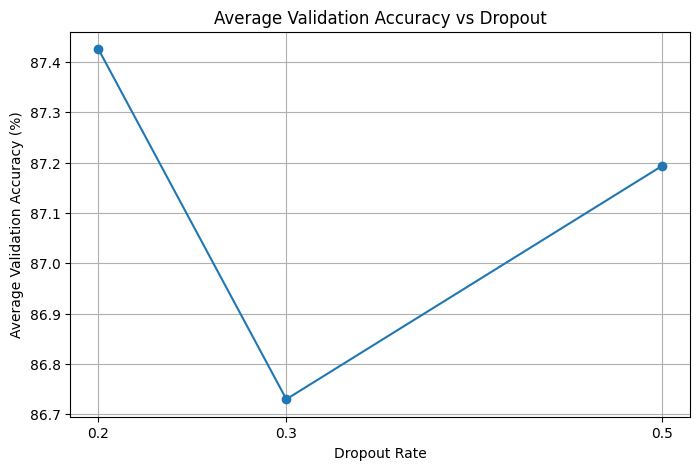

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_results["dropout"],
    dropout_results["val_acc"],
    marker="o"
)

plt.title(
    "Average Validation Accuracy vs Dropout"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Average Validation Accuracy (%)")

plt.xticks(
    dropout_results["dropout"]
)

plt.grid(True)
plt.show()

In [13]:
augmentation_order = [
    "Low",
    "Medium",
    "High"
]

augmentation_results = (
    df.groupby(
        "augmentation_level",
        as_index=False
    )["val_acc"]
    .mean()
)

augmentation_results[
    "augmentation_level"
] = pd.Categorical(
    augmentation_results[
        "augmentation_level"
    ],
    categories=augmentation_order,
    ordered=True
)

augmentation_results = (
    augmentation_results
    .sort_values("augmentation_level")
)

augmentation_results

,augmentation_level,val_acc
1,Low,87.425
2,Medium,88.020
0,High,86.135


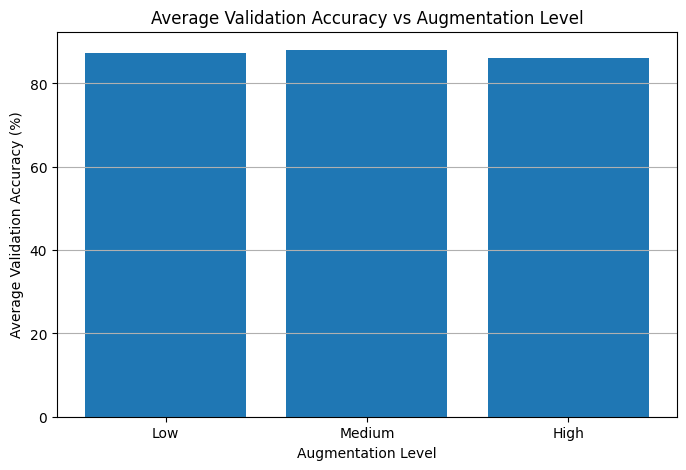

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(
    augmentation_results[
        "augmentation_level"
    ].astype(str),
    augmentation_results["val_acc"]
)

plt.title(
    "Average Validation Accuracy vs Augmentation Level"
)

plt.xlabel("Augmentation Level")
plt.ylabel("Average Validation Accuracy (%)")

plt.grid(axis="y")
plt.show()

In [15]:
time_by_image_size = (
    df.groupby("image_size", as_index=False)
    ["training_time_minutes"]
    .mean()
    .sort_values("image_size")
)

time_by_image_size

,image_size,training_time_minutes
0,160,3.615
1,224,3.900
2,260,4.925


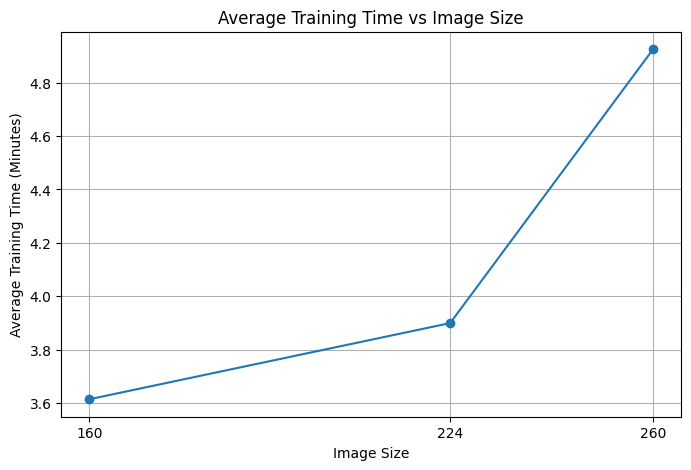

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    time_by_image_size["image_size"],
    time_by_image_size[
        "training_time_minutes"
    ],
    marker="o"
)

plt.title(
    "Average Training Time vs Image Size"
)

plt.xlabel("Image Size")
plt.ylabel("Average Training Time (Minutes)")

plt.xticks(
    time_by_image_size["image_size"]
)

plt.grid(True)
plt.show()

In [17]:
print("Average validation accuracy by image size:")
print(image_size_results.to_string(index=False))

print("\nAverage validation accuracy by dropout:")
print(dropout_results.to_string(index=False))

print("\nAverage validation accuracy by augmentation:")
print(augmentation_results.to_string(index=False))

Average validation accuracy by image size:
 image_size  val_acc
        160   85.840
        224   87.225
        260   88.515

Average validation accuracy by dropout:
 dropout   val_acc
     0.2 87.425000
     0.3 86.730000
     0.5 87.193333

Average validation accuracy by augmentation:
augmentation_level  val_acc
               Low   87.425
            Medium   88.020
              High   86.135


In [19]:
readme_summary = (
    "Best of six sweep runs: "
    f"{best_run['val_acc']:.2f}% validation accuracy "
    f"with image_size={int(best_run['image_size'])}, "
    f"dropout={best_run['dropout']}, "
    f"augmentation="
    f"{best_run['augmentation_level']}."
)

print(readme_summary)

Best of six sweep runs: 89.31% validation accuracy with image_size=260, dropout=0.5, augmentation=Medium.


# Hyperparameter Sweep Interpretation

Six EfficientNetB0 feature-extraction experiments were completed using different image sizes, dropout rates, and augmentation strengths.

## Best Run

The best-performing experiment was **Run 6**, with the following configuration:

- **Image size:** 260 × 260
- **Dropout:** 0.5
- **Augmentation:** Medium
- **Training accuracy:** 83.33%
- **Validation accuracy:** 89.31%
- **Training time:** 4.86 minutes

## Interpretation

Image size appeared to have the clearest positive relationship with validation performance. The experiments using 260 × 260 images achieved stronger validation results overall, although they required more training time than the 160 × 160 and 224 × 224 configurations.

Dropout had a less consistent effect because the same dropout value produced different results when combined with different image sizes and augmentation strengths. However, the best run used a dropout rate of 0.5, suggesting that stronger regularization was beneficial when using larger images and medium augmentation.

Medium augmentation produced the best individual experiment. High augmentation did not consistently improve performance and produced the lowest validation accuracy in Run 2. This suggests that excessive augmentation may make the training task unnecessarily difficult.

## Recommended Default Settings for CESPPL

Based on this small sweep, the initial CESPPL configuration should use:

- **Image size:** 260 × 260
- **Dropout:** 0.5
- **Augmentation:** Medium
- **Batch size:** 32
- **Backbone:** EfficientNetB0
- **Learning rate:** 0.001 for feature extraction

These settings should be treated as a starting point rather than a guaranteed optimum because the sweep contained only six runs. Dataset quality and training discipline remain more important than small differences between reasonable hyperparameter values.